In [27]:
import deepinv as dinv
import torch
import pywt
import ptwt

PSNR = dinv.metric.PSNR()

import deepinv
import os
print(os.path.dirname(deepinv.__file__))

x_true = dinv.utils.load_example("butterfly.png", device='cpu')

/home/edgar/Documents/Git repositories/deepinv/deepinv


In [ ]:
print('With pywt:')
for mode in pywt.Modes.modes:
    print(f"\nWith padding mode {mode}:")
    x_wav = pywt.wavedec2(x_true.cpu().numpy(), 'db8', mode='zero', level=3)
    print(torch.from_numpy(x_wav[0]).shape)  # Approximation coefficients
    print(torch.from_numpy(x_wav[1][0]).shape)  # Horizontal detail

print('\nWith ptwt:')
modes = ['constant', 'zero', 'reflect', 'periodic', 'symmetric']
for mode in modes:

    print(f"\nWith padding mode {mode}:")
    x_wav = ptwt.wavedec2(x_true, 'db8', mode=mode, level=3)
    print(x_wav[0].shape)
    print(x_wav[1][0].shape)

With pywt:

With padding mode zero:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode constant:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode symmetric:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode periodic:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode smooth:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode periodization:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode reflect:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode antisymmetric:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode antireflect:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With ptwt:

With padding mode constant:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode zero:
torch.Size([1, 3, 45, 45])
torch.Size([1, 3, 45, 45])

With padding mode reflect:
torch.Size([1, 3, 45, 45])
torch.

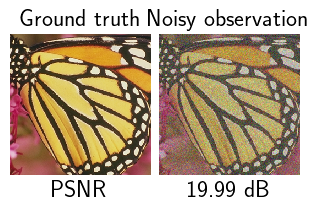

In [19]:
gaussian_noise = dinv.physics.GaussianNoise(sigma=0.1)
physics = dinv.physics.Denoising(gaussian_noise)

y = physics(x_true)
psnr_y = PSNR(x_true, y).item()

dinv.utils.plot([x_true, y], titles=['Ground truth', f'Noisy observation'], subtitles=['PSNR', f'{psnr_y:.2f} dB'], cmap='gray')

### Denoising with DeepInv's WaveletDenoiser

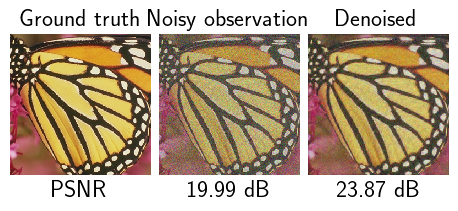

In [20]:
wavelet_denoiser = dinv.models.WaveletDenoiser(level=3, wv='db8')

y_denoised = wavelet_denoiser(y, ths=0.1)
psnr_y_denoised = PSNR(x_true, y_denoised).item()

dinv.utils.plot([x_true, y, y_denoised], titles=['Ground truth', f'Noisy observation', f'Denoised'], subtitles=['PSNR', f'{psnr_y:.2f} dB', f'{psnr_y_denoised:.2f} dB'])

### Custom wavelet denoising

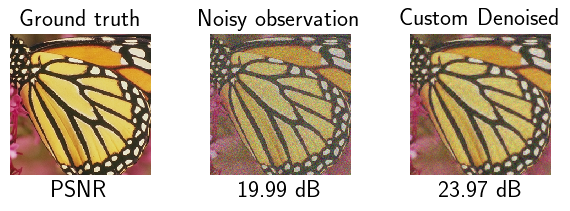

In [21]:
y_wavelet = pywt.wavedec2(y.cpu().numpy(), 'db8', level=3)
y_wavelet_thresholded = [y_wavelet[0]]

soft_thresholding = lambda x, thresh: dinv.optim.L1Prior().prox(x=x, gamma=thresh)

for j in range(1, len(y_wavelet)):
    y_wavelet_thresholded.append(
        tuple(
            soft_thresholding(
                torch.from_numpy(y_wavelet[j][c]),
                thresh=0.1
            ).numpy() for c in range(3)
        )
    )

y_denoised_custom = torch.from_numpy(pywt.waverec2(y_wavelet_thresholded, 'db8'))

dinv.utils.plot([x_true, y, y_denoised_custom], titles=['Ground truth', f'Noisy observation', f'Custom Denoised'], subtitles=['PSNR', f'{psnr_y:.2f} dB', f'{PSNR(x_true, y_denoised_custom).item():.2f} dB'], cmap='gray', tight=False)

### Comparing reconstructions

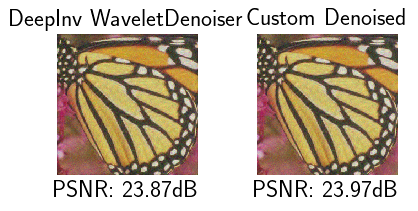

Norm of the difference: 5.560732841491699


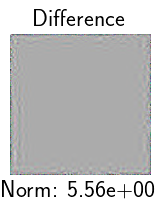

tensor([[[[ 1.7881e-07,  1.7881e-07,  0.0000e+00,  2.9802e-07,  0.0000e+00,
           -2.3842e-07, -4.1723e-07, -3.5763e-07,  2.3842e-07,  1.1921e-07],
          [ 5.3644e-07,  5.9605e-08,  5.9605e-08,  1.7881e-07, -2.3842e-07,
           -7.1526e-07, -2.3842e-07, -4.1723e-07,  4.1723e-07,  0.0000e+00],
          [ 2.9802e-07,  3.5763e-07,  8.3447e-07,  5.3644e-07,  1.7881e-07,
           -1.7881e-07, -5.9605e-08, -1.1921e-07,  5.9605e-08, -2.3842e-07],
          [ 2.3842e-07,  4.1723e-07,  8.9407e-07,  6.5565e-07,  1.7881e-07,
           -5.9605e-08,  1.7881e-07,  1.1921e-07,  5.9605e-08, -2.3842e-07],
          [ 5.3644e-07,  1.0133e-06,  5.3644e-07,  2.9802e-07,  5.9605e-08,
           -5.9605e-08,  2.3842e-07,  2.9802e-07,  0.0000e+00, -1.7881e-07],
          [ 4.1723e-07,  7.7486e-07,  4.1723e-07,  1.7881e-07,  1.7881e-07,
            4.1723e-07,  4.1723e-07,  1.7881e-07, -1.1921e-07, -1.1921e-07],
          [ 0.0000e+00,  4.1723e-07,  5.3644e-07,  4.7684e-07,  4.7684e-07,
      

In [33]:
dinv.utils.plot([y_denoised, y_denoised_custom], subtitles=[f'PSNR: {psnr_y_denoised:.2f}dB', f'PSNR: {PSNR(x_true, y_denoised_custom).item():.2f}dB'], titles=[f'DeepInv WaveletDenoiser', f'Custom Denoised'], tight=False)

print(f'Norm of the difference: {torch.norm(y_denoised - y_denoised_custom).item()}')

dinv.utils.plot([y_denoised - y_denoised_custom], titles=['Difference'], subtitles=[f'Norm: {torch.norm(y_denoised - y_denoised_custom).item():.2e}'], tight=False)
print((y_denoised - y_denoised_custom)[...,100:110, 100:110])